In [1]:
from sallypy.repos import TimeSeriesRepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch


ts_repo = TimeSeriesRepo()
returns = ts_repo.get_monthly_returns(["BMK0017", "BMK0188"])
returns.columns = ["Bonds", "Stocks"]
returns.dropna(inplace=True)
yearly_returns = returns.resample("YE").apply(lambda x: (1 + x).prod() - 1)
yearly_cov = yearly_returns.cov()

In [171]:
def cholesky_bootstrap_returns(n: int, s: int, cov: pd.DataFrame, exp_ret: pd.DataFrame) -> np.ndarray:
    """
    Simulate returns using the Cholesky decomposition of the covariance matrix.
    Parameters
    ----------
    n : int
        Number of simulations.
    s : int
        Length of the simulation.
    cov : pandas.DataFrame
        Covariance matrix.
    exp_ret : pandas.DataFrame
        Expected returns.

    Returns
    -------
    np.array
        n x s x num_assets tensor

    """
    rng = np.random.default_rng()
    y = rng.multivariate_normal(exp_ret.values.flatten(), cov.values, size=(n, s))
    return y


def simulate_wealth(
    simulated_returns: np.ndarray,
    weights: np.ndarray,
    initial_wealth: float,
    cashflows: np.ndarray,
    transactions: np.ndarray,
    inflation: float = 0.03,
    time_steps: np.ndarray = None,
) -> np.ndarray:
    """
    Simulate wealth using the simulated returns and weights.
    Parameters
    ----------
    simulated_returns : np.array
        n x s x n_assets tensor of simulated returns.
    weights : np.array
        s x num_assets matrix of weights.
    initial_wealth : float
        Initial wealth.
    cashflows : np.array
        s x 1 vector of cashflows.
    transactions : np.array
        s x 1 vector of transactions.
    inflation : float, optional
        Inflation rate. Default is 0.03.
    time_steps : np.array, optional
        s+1 x 1 vector of time steps. If None, will be set to np.arange(0, s + 1).
    Returns
    -------
    np.array
        n x s+1 matrix of wealth.
    """

    n = simulated_returns.shape[0]  # number of simulations
    s = simulated_returns.shape[1]  # number of time steps
    k = simulated_returns.shape[2]  # number of assets

    wealth = np.zeros((n, s + 1))  # wealth array
    wealth[:, 0] = initial_wealth  # set initial wealth
    if time_steps is None:
        time_steps = np.arange(0, s + 1)  # time steps
    time_delta = np.diff(time_steps)  # time delta

    assert len(cashflows) == s, "Cashflows must be the same length as the number of time steps"
    assert len(transactions) == s, "Transactions must be the same length as the number of time steps"
    assert len(time_steps) == s + 1, "Time steps must be the same length as the number of time steps + 1"
    assert weights.shape[0] == s, "Weights first dimension must be the same length as the number of time steps"
    assert weights.shape[1] == k, "Weights second dimension must be the same length as the number of assets"
    assert len(time_delta) == s, "Time delta must be the same length as the number of time steps - 1"
    assert np.all(time_delta > 0), "Time steps must be in ascending order"
    assert np.all(np.isfinite(simulated_returns)), "Simulated returns must be finite"
    assert np.all(np.isfinite(weights)), "Weights must be finite"
    assert np.all(np.isfinite(cashflows)), "Cashflows must be finite"
    assert np.all(np.isfinite(transactions)), "Transactions must be finite"
    assert np.all(np.isfinite(initial_wealth)), "Initial wealth must be finite"
    assert np.all(np.isfinite(time_steps)), "Time steps must be finite"

    inflation_factor = 1
    for i in range(s):
        inflation_factor *= (1 + inflation) ** time_delta[i]
        wealth[:, i + 1] = (
            wealth[:, i] * (weights[i] * (1 + simulated_returns[:, i, :]) ** time_delta[i]).sum(axis=1)
            + (cashflows[i] * time_delta[i] + transactions[i]) * inflation_factor
        )
        wealth[wealth[:, i + 1] < 0, i + 1] = 0  # set negative wealth to 0

    return wealth


def simulate_wealth_torch(
    simulated_returns: torch.Tensor,
    weights: torch.Tensor,
    initial_wealth: float,
    cashflows: torch.Tensor,
    transactions: torch.Tensor,
    inflation: float = 0.03,
    time_steps: torch.Tensor = None,
) -> torch.Tensor:
    """
    Simulate wealth using the simulated returns and weights with PyTorch.
    Parameters
    ----------
    simulated_returns : torch.Tensor
        n x s x n_assets tensor of simulated returns.
    weights : torch.Tensor
        s x num_assets matrix of weights.
    initial_wealth : float
        Initial wealth.
    cashflows : torch.Tensor
        s x 1 vector of cashflows.
    transactions : torch.Tensor
        s x 1 vector of transactions.
    inflation : float, optional
        Inflation rate. Default is 0.03.
    time_steps : torch.Tensor, optional
        s+1 x 1 vector of time steps. If None, will be set to torch.arange(0, s + 1).

    Returns
    -------
    torch.Tensor
        n x s+1 matrix of wealth.
    """

    n = simulated_returns.shape[0]  # number of simulations
    s = simulated_returns.shape[1]  # number of time steps
    k = simulated_returns.shape[2]  # number of assets

    wealth = torch.zeros((n, s + 1))  # wealth array
    wealth[:, 0] = initial_wealth  # set initial wealth
    if time_steps is None:
        time_steps = torch.arange(0, s + 1)  # time steps
    time_delta = torch.diff(time_steps)  # time delta

    assert len(cashflows) == s, "Cashflows must be the same length as the number of time steps"
    assert len(transactions) == s, "Transactions must be the same length as the number of time steps"
    assert len(time_steps) == s + 1, "Time steps must be the same length as the number of time steps + 1"
    assert weights.shape[0] == s, "Weights first dimension must be the same length as the number of time steps"
    assert weights.shape[1] == k, "Weights second dimension must be the same length as the number of assets"
    assert len(time_delta) == s, "Time delta must be the same length as the number of time steps - 1"
    # assert torch.all(time_delta > 0), "Time steps must be in ascending order"
    # assert torch.all(torch.isfinite(simulated_returns)), "Simulated returns must be finite"
    # assert torch.all(torch.isfinite(weights)), "Weights must be finite"
    # assert torch.all(torch.isfinite(cashflows)), "Cashflows must be finite"
    # assert torch.all(torch.isfinite(transactions)), "Transactions must be finite"
    # assert torch.isfinite(initial_wealth), "Initial wealth must be finite"
    # assert torch.all(torch.isfinite(time_steps)), "Time steps must be finite"
    inflation_factor = 1
    for i in range(s):
        inflation_factor *= (1 + inflation) ** time_delta[i]
        wealth[:, i + 1] = (
            wealth[:, i] * (weights[i] * (1 + simulated_returns[:, i, :]) ** time_delta[i]).sum(axis=1)
            + (cashflows[i] * time_delta[i] + transactions[i]) * inflation_factor
        )
        # Replace in-place assignment with out-of-place operation
        wealth[:, i + 1] = torch.where(wealth[:, i + 1] < 0, torch.zeros_like(wealth[:, i + 1]), wealth[:, i + 1])
    return wealth


def total_destitution_cost(cost_, wealth, sharpness=1e-5, only_retirement=False, retirement_year=27):
    if only_retirement:
        return cost_ + -torch.sigmoid(wealth[retirement_year + 1 :, :] * sharpness).sum() / (
            wealth.shape[0] * (wealth.shape[1] - 1)
        )
    else:
        return cost_ + -torch.sigmoid(wealth[1:, :] * sharpness).sum() / (wealth.shape[0] * (wealth.shape[1] - 1))


def final_destitution_cost(cost_, wealth, sharpness=1e-5):
    return cost_ + -torch.sigmoid(wealth[-1, :] * sharpness).sum() / (wealth.shape[0] * (wealth.shape[1] - 1))


def weight_smoothing(cost_, weights, smoothing=1 / 10, alpha=0.5):
    s_m1 = weights[0, :]
    for z in range(1, weights.shape[0]):
        s_m1 = weights[z, :]
        x_z = weights[z - 1, :]
        s_z = s_m1 - alpha * (x_z - s_m1)
        cost_ += torch.sum((x_z - s_z) ** 2) / weights.shape[1] * smoothing
    return cost_


def weight_smoothing_about_retirement(cost_, weights, smoothing=1 / 10, alpha=0.4, retirement_year=27):
    s_m1 = weights[0, :]
    for z in range(1, retirement_year):
        s_m1 = weights[z, :]
        x_z = weights[z - 1, :]
        s_z = s_m1 - alpha * (x_z - s_m1)
        cost_ += torch.sum((x_z - s_z) ** 2) / weights.shape[1] * smoothing

    # Post-retirement smoothing
    s_m1 = weights[retirement_year, :]
    for z in range(1, S - retirement_year):
        s_m1 = weights[retirement_year + z, :]
        x_z = weights[retirement_year + z - 1, :]
        s_z = s_m1 - alpha * (x_z - s_m1)
        cost_ += torch.sum((x_z - s_z) ** 2) / weights.shape[1] * smoothing

    return cost_


def get_weights_from_control_matrix(
    wealth_at_t: torch.Tensor,
    control_matrix: torch.Tensor,
    time_step: int,
    max_wealth: float | np.ndarray = 1e7,
) -> torch.Tensor:
    """
    Get weights from the control matrix for a given time step.
    Parameters
    ----------
    wealth_at_t : torch.Tensor
        n x 1 tensor of wealth at time step t.
    control_matrix : torch.Tensor
        W_steps x S_TIMESTEPS tensor of control matrix.
    time_step : int
        Time step to get the weights for.
    Returns
    -------
    torch.Tensor
        n x 1 tensor of weights at time step t.
    """
    W_steps = control_matrix.shape[0]
    control = control_matrix[:, time_step]
    if not isinstance(max_wealth, (int, float)):
        max_wealth = max_wealth[time_step]

    if isinstance(max_wealth, (int, float)):
        max_wealth = float(max_wealth)

    wealth_grid = torch.tensor(np.linspace(1, max_wealth, W_steps), device=control.device)

    # wealth_grid = wealth_grid.log10()
    # wealth_at_t = (wealth_at_t + 1).log10()

    lower_i = torch.clamp(torch.searchsorted(wealth_grid, (wealth_at_t + 1), right=True) - 1, 0, W_steps - 1)
    # lower_i = torch.clamp(
    #     torch.searchsorted(wealth_grid, wealth_at_t + 1, right=True) - 1, 0, W_steps-1
    # )
    # upper_i = torch.clamp(lower_i + 1, 0, W_steps-1)

    # w_0 = wealth_grid[lower_i]
    # w_1 = wealth_grid[upper_i]

    # beta = (wealth_at_t - w_0) / (w_1 - w_0)

    w_0 = control[lower_i]
    # w_1 = control[upper_i]

    # w = w_0 + beta * (w_1 - w_0)
    # w = w.nan_to_num(nan=control.detach().numpy()[-1])  # Replace nan with last control value

    # return w.T
    return w_0


def control_matrix_smoothing_cost(cost_, control_matrix: torch.Tensor, smoothing=1/1000, alpha=0.1):
    """
    Calculate the smoothing cost for the control matrix.
    Parameters
    ----------
    cost_ : torch.Tensor
        Initial cost.
    control_matrix : torch.Tensor
        W_steps x S_TIMESTEPS tensor of control matrix.
    smoothing : float, optional
        Smoothing factor. Default is 1/10.
    alpha : float, optional
        Smoothing parameter. Default is 0.5. Higher values lead to more smoothing.
    Returns
    -------
    torch.Tensor
        Updated cost with smoothing applied.
    """
    W_steps, S_TIMESTEPS = control_matrix.shape
    s_m1 = control_matrix[0, :]

    # Smoothing in wealth space
    for z in range(1, W_steps):
        s_m1 = control_matrix[z, :]
        x_z = control_matrix[z - 1, :]
        s_z = s_m1 - alpha * (x_z - s_m1)
        cost_ += torch.sum((x_z - s_z) ** 2) / S_TIMESTEPS * smoothing

    # Smoothing in time space
    for t in range(1, S_TIMESTEPS):
        s_m1 = control_matrix[:, t]
        x_t = control_matrix[:, t-1]
        s_t = s_m1 - alpha * (x_t - s_m1)
        cost_ += torch.sum((x_t - s_t)**2) / W_steps * smoothing
    return cost_

In [178]:
def simulate_wealth_torch(
    simulated_returns: torch.Tensor,
    weights: torch.Tensor,
    initial_wealth: float,
    cashflows: torch.Tensor,
    transactions: torch.Tensor,
    inflation: float = 0.03,
    time_steps: torch.Tensor = None,
) -> torch.Tensor:
    n = simulated_returns.shape[0]  # number of simulations
    s = simulated_returns.shape[1]  # number of time steps
    k = simulated_returns.shape[2]  # number of assets

    if time_steps is None:
        time_steps = torch.arange(0, s + 1)
    time_delta = torch.diff(time_steps)

    wealth_steps = []
    wealth_t = torch.full((n,), initial_wealth, dtype=simulated_returns.dtype, device=simulated_returns.device)
    wealth_steps.append(wealth_t)

    inflation_factor = 1
    for i in range(s):

        stock_weight = weights[i, 0]
        bond_weight = 1 - weights[i, 0] 

        inflation_factor *= (1 + inflation) ** time_delta[i]
        next_wealth = (
            wealth_t * 
            (
                (bond_weight * (1 + simulated_returns[:, i, 0]) ** time_delta[i] + stock_weight * (1 + simulated_returns[:, i, 1]) ** time_delta[i])
            )
            + (cashflows[i] * time_delta[i] + transactions[i]) * inflation_factor
        )
        next_wealth = torch.where(next_wealth < 0, torch.zeros_like(next_wealth), next_wealth)
        wealth_steps.append(next_wealth)
        wealth_t = next_wealth

    wealth = torch.stack(wealth_steps, dim=1)
    return wealth

def simulate_wealth_torch_control(
    simulated_returns: torch.Tensor,
    control_matrix: torch.Tensor,
    initial_wealth: float | np.ndarray,
    cashflows: torch.Tensor,
    transactions: torch.Tensor,
    inflation: float = 0.03,
    time_steps: torch.Tensor = None,
    max_wealth: float | np.ndarray = 1e7,
) -> torch.Tensor:
    n = simulated_returns.shape[0]  # number of simulations
    s = simulated_returns.shape[1]  # number of time steps
    k = simulated_returns.shape[2]  # number of assets

    if time_steps is None:
        time_steps = torch.arange(0, s + 1)
    time_delta = torch.diff(time_steps)

    wealth_steps = []

    if isinstance(initial_wealth, (int, float)):
        initial_wealth = np.ones((n,)) * initial_wealth

    # wealth_t = torch.full((n,), initial_wealth, dtype=simulated_returns.dtype, device=simulated_returns.device)
    wealth_t = torch.tensor(initial_wealth, dtype=simulated_returns.dtype, device=simulated_returns.device)
    wealth_steps.append(wealth_t)
    print("Device:", wealth_t.device, "Control Matrix Device:", control_matrix.device)

    

    inflation_factor = 1
    for i in range(s):
        weights = get_weights_from_control_matrix(wealth_t, control_matrix, i, max_wealth)
        # print(weights)
        stock_weight = weights[0]
        bond_weight = 1 - stock_weight

        inflation_factor *= (1 + inflation) ** time_delta[i]
        next_wealth = (
            wealth_t * 
            (
                (bond_weight * (1 + simulated_returns[:, i, 0]) ** time_delta[i] + stock_weight * (1 + simulated_returns[:, i, 1]) ** time_delta[i])
            )
            + (cashflows[i] * time_delta[i] + transactions[i]) * inflation_factor
        )
        next_wealth = torch.where(next_wealth < 0, torch.zeros_like(next_wealth), next_wealth)
        wealth_steps.append(next_wealth)
        wealth_t = next_wealth

    wealth = torch.stack(wealth_steps, dim=1)
    return wealth

def simulate_max_wealth_no_treatment(initial_wealth, cashflows, transactions):
    mc_returns = torch.tensor(
        cholesky_bootstrap_returns(
            n=N_SIMULATIONS,
            s=S_TIMESTEPS,
            cov=yearly_cov,
            exp_ret=yearly_returns.mean(),
        ),
        dtype=torch.float32,
        device='cuda'
    )
    
    contol_control_matrix = torch.tensor(
        np.array(
            [
                np.array([1] * S_TIMESTEPS) for W_step in range(20)
            ]
        ),
        dtype=torch.float32,
        requires_grad=True,
        device='cuda'
    )

    wealth_no_treatment = simulate_wealth_torch_control(
        simulated_returns=mc_returns,
        control_matrix=contol_control_matrix,
        initial_wealth=initial_wealth,
        cashflows=cashflows,
        transactions=transactions,
    )

    wealth = wealth_no_treatment.cpu().detach().numpy()
    _95_percentile = np.percentile(wealth, 95, axis=0)
    return _95_percentile[1:]  # Exclude the initial wealth step (0th step)


S_TIMESTEPS = 40
N_SIMULATIONS = 500000


torch.cuda.empty_cache()  # Clear GPU memory


mc_returns = torch.tensor(
    cholesky_bootstrap_returns(
        n=N_SIMULATIONS,
        s=S_TIMESTEPS,
        cov=yearly_cov,
        exp_ret=yearly_returns.mean(),
    ),
    dtype=torch.float32,
    device='cuda'
)



N_ASSETS = mc_returns.shape[2]

initial_wealth = np.random.uniform(0, 2000000, N_SIMULATIONS)
# cashflows = torch.zeros((S_TIMESTEPS, 1), dtype=torch.float32, requires_grad=False)
transactions = torch.zeros((S_TIMESTEPS, 1), dtype=torch.float32, requires_grad=False, device='cuda')

RETIRMENT_YEAR = 0 # years
cashflows = np.zeros(S_TIMESTEPS) # cashflows
# cashflows[RETIRMENT_YEAR:] = -50000 # cashflows after retirement
# cashflows[:RETIRMENT_YEAR] = np.linspace(5000, 15000, RETIRMENT_YEAR) # cashflows before retirement (e.g. savings)
cashflows = np.ones(S_TIMESTEPS) * -50000
cashflows = torch.tensor(cashflows, dtype=torch.float32, requires_grad=False, device='cuda')
# cashflows = cashflows.to(device="cuda")

control_matrix = torch.tensor(
    np.array(
        [
            np.array([0.6] * S_TIMESTEPS) for W_step in range(50)
        ]
    ),
    # np.random.uniform(0, 1, (50, S_TIMESTEPS)),
    dtype=torch.float32,
    requires_grad=True,
    device='cuda'
)
control_matrix.data.clamp_(0, 1)  # Ensure weights are between 0 and 1

# max_wealth = simulate_max_wealth_no_treatment(
#     initial_wealth=initial_wealth,
#     cashflows=cashflows, 
#     transactions=transactions
#     )

max_wealth = 5e6

def plot_wealth_distribution(wealth: torch.Tensor, time_step: int):
    """
    Plot the distribution of wealth at a given time step.
    Parameters
    ----------
    wealth : torch.Tensor
        n x s+1 matrix of wealth.
    time_step : int
        Time step to plot the distribution for.
    """
    sns.histplot(wealth[:, time_step].detach().numpy(), bins=100, kde=True)
    plt.title(f"Wealth Distribution at Time Step {time_step}")
    plt.xlabel("Wealth")
    plt.ylabel("Frequency")
    plt.show()


optimizer = torch.optim.Adam([control_matrix], lr=0.002)
optimizer.zero_grad()

# wealth = simulate_wealth_torch(
#     simulated_returns=mc_returns,
#     weights=weights,
#     initial_wealth=initial_wealth,
#     cashflows=cashflows,
#     transactions=transactions,
# )


mc_returns = torch.tensor(
    cholesky_bootstrap_returns(
        n=N_SIMULATIONS,
        s=S_TIMESTEPS,
        cov=yearly_cov,
        exp_ret=yearly_returns.mean(),
    ),
    dtype=torch.float32,
    device='cuda'
)
    

for optim_step in range(1000):
    print(optim_step)
    optimizer.zero_grad()
    # Simulate wealth using the control matrix

    mc_returns = torch.tensor(
        cholesky_bootstrap_returns(
            n=N_SIMULATIONS,
            s=S_TIMESTEPS,
            cov=yearly_cov,
            exp_ret=yearly_returns.mean(),
        ),
        dtype=torch.float32,
        device='cuda'
    )

    wealth = simulate_wealth_torch_control(
        simulated_returns=mc_returns,
        control_matrix=control_matrix,
        initial_wealth=initial_wealth,
        cashflows=cashflows,
        transactions=transactions,
        max_wealth=max_wealth,
    )
    cost_ = torch.zeros(1,requires_grad=True, device='cuda')
    cost_ = total_destitution_cost(cost_, wealth.T, sharpness=0.000001)
    cost_ = final_destitution_cost(cost_, wealth.T)
    cost_ = control_matrix_smoothing_cost(cost_, control_matrix)
    cost_.backward(retain_graph=True)

    optimizer.step()
    with torch.no_grad():
        control_matrix.clamp_(0.0, 1.0)
    # del mc_returns
    print("destitution risk", torch.sum(wealth[:, -1] <= 0).item()/N_SIMULATIONS)
    print("total destituion risk", torch.sum(wealth <= 0).item()/(N_SIMULATIONS*S_TIMESTEPS))

# wealth = simulate_wealth_torch_control(
#     simulated_returns=mc_returns,
#     control_matrix=control_matrix,
#     initial_wealth=initial_wealth,
#     cashflows=cashflows,
#     transactions=transactions,
# )
# cost_ = torch.zeros(1,)
# cost_ = total_destitution_cost(cost_, wealth)
# cost_.backward(retain_graph=True)
# optimizer.step()

# print the optimized weights
# print("Optimized Weights:")
print(control_matrix.cpu().detach().numpy())

0
Device: cuda:0 Control Matrix Device: cuda:0
destitution risk 0.433128
total destituion risk 0.28826315
1
Device: cuda:0 Control Matrix Device: cuda:0
destitution risk 0.432614
total destituion risk 0.28788545
2
Device: cuda:0 Control Matrix Device: cuda:0
destitution risk 0.432516
total destituion risk 0.28784085
3
Device: cuda:0 Control Matrix Device: cuda:0
destitution risk 0.432894
total destituion risk 0.2876828
4
Device: cuda:0 Control Matrix Device: cuda:0
destitution risk 0.433246
total destituion risk 0.28800125
5
Device: cuda:0 Control Matrix Device: cuda:0
destitution risk 0.433358
total destituion risk 0.28785375
6
Device: cuda:0 Control Matrix Device: cuda:0
destitution risk 0.431582
total destituion risk 0.2873714
7
Device: cuda:0 Control Matrix Device: cuda:0
destitution risk 0.432726
total destituion risk 0.2878864
8
Device: cuda:0 Control Matrix Device: cuda:0
destitution risk 0.432252
total destituion risk 0.2875978
9
Device: cuda:0 Control Matrix Device: cuda:0
des

Device: cuda:0 Control Matrix Device: cuda:0


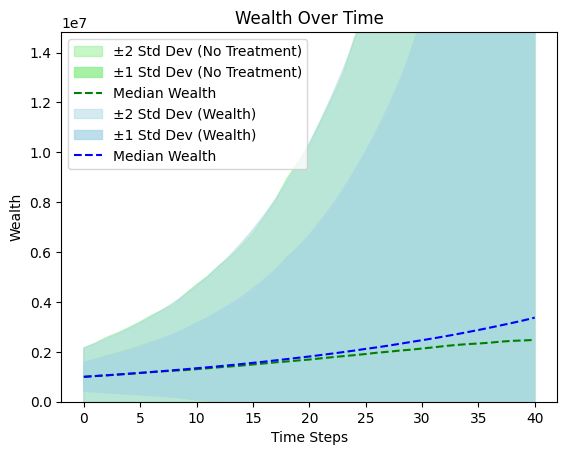

In [179]:
mc_returns = torch.tensor(
    cholesky_bootstrap_returns(
        n=N_SIMULATIONS,
        s=S_TIMESTEPS,
        cov=yearly_cov,
        exp_ret=yearly_returns.mean(),
    ),
    dtype=torch.float32,
    device='cuda'
)

contol_control_matrix = torch.tensor(
    # np.array(
    #     [
    #         np.array([0] * S_TIMESTEPS) for W_step in range(50)
    #     ]
    # ),
    np.random.uniform(0, 1, (50, S_TIMESTEPS)),
    dtype=torch.float32,
    requires_grad=True,
    device='cuda'
)

wealth_no_treatment = simulate_wealth_torch_control(
    simulated_returns=mc_returns,
    control_matrix=contol_control_matrix,
    initial_wealth=initial_wealth,
    cashflows=cashflows,
    transactions=transactions,
    max_wealth=max_wealth,
)

def plot_wealth(wealth: torch.Tensor, label: str = "Wealth", color: str = "blue"):
    """
    Plot the mean wealth over time.
    Parameters
    ----------
    wealth : torch.Tensor
        n x s+1 matrix of wealth.
    """
    wealth_np = wealth.detach().cpu().numpy()
    median_wealth = np.median(wealth_np, axis=0)
    _1std = wealth_np.std(axis=0)
    _2std = 2 * _1std
    lower_bound = wealth_np.mean(axis=0) - _2std
    upper_bound = wealth_np.mean(axis=0) + _2std
    plt.fill_between(
        np.arange(wealth_np.shape[1]),
        lower_bound,
        upper_bound,
        color="light" + color,
        alpha=0.5,
        label="±2 Std Dev" + " (" + label + ")"
    )
    plt.fill_between(
        np.arange(wealth_np.shape[1]),
        wealth_np.mean(axis=0) - _1std,
        wealth_np.mean(axis=0) + _1std,
        color="light" + color,
        alpha=0.8,
        label="±1 Std Dev" + " (" + label + ")"
    )
    # plt.plot(
    #     wealth_np.mean(axis=0),
    #     label="Mean Wealth",
    #     color= color,
    #     linewidth=2,
    # )
    plt.plot(
        median_wealth,
        label="Median Wealth",
        color= color,
        linestyle="--",
    )
    plt.title("Wealth Over Time")
    plt.xlabel("Time Steps")
    plt.ylabel("Wealth")
    plt.legend()
    plt.ylim(0, max(wealth_np.mean(axis=0)) * 1.1)

plot_wealth(wealth_no_treatment, label="No Treatment", color="green")
plot_wealth(wealth)


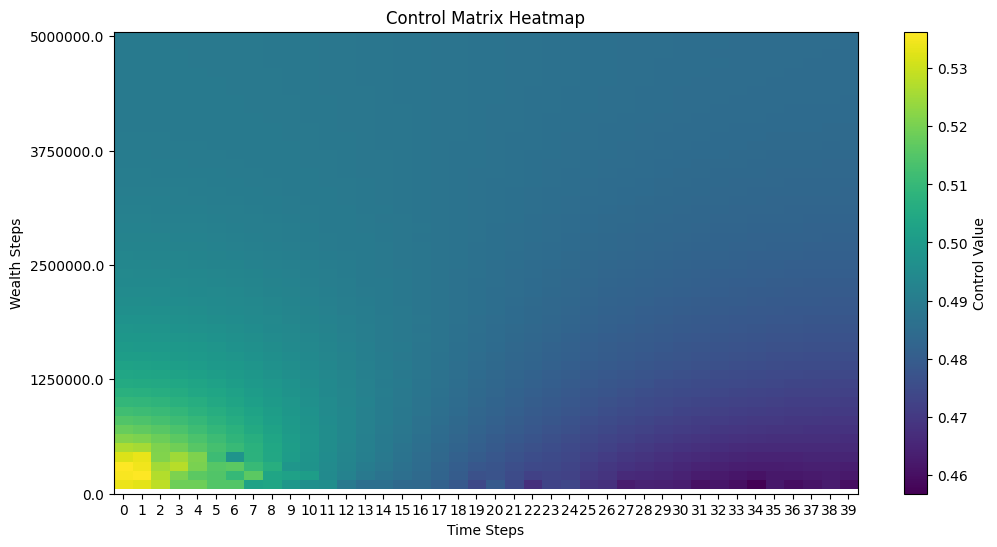

In [180]:
def plot_control_matrix(control_matrix: torch.Tensor):
    """
    Plot the control matrix.
    Parameters
    ----------
    control_matrix : torch.Tensor
        W_steps x S_TIMESTEPS tensor of control matrix.
    """
    plt.figure(figsize=(12, 6))
    # set colormap to viridis (0-1)
    plt.imshow(
        np.flip(control_matrix.detach().cpu().numpy(), axis=0),
        cmap="viridis",
        aspect='auto',
        interpolation='nearest'
    )
    plt.colorbar(label="Control Value")
    # sns.heatmap(control_matrix.detach().cpu().numpy(), cmap="viridis", cbar=True)
    plt.title("Control Matrix Heatmap")
    plt.xlabel("Time Steps")
    plt.ylabel("Wealth Steps")
    plt.xticks(ticks=np.arange(S_TIMESTEPS), labels=np.arange(S_TIMESTEPS))
    plt.yticks(ticks=np.linspace(0, control_matrix.shape[0], 5), labels=np.linspace(max_wealth, 0, 5))
    plt.show()

plot_control_matrix(control_matrix)

In [ ]:
def control_matrix_smoothing_cost(cost_, control_matrix: torch.Tensor, smoothing=1/10, alpha=0.5):
    """
    Calculate the smoothing cost for the control matrix.
    Parameters
    ----------
    cost_ : torch.Tensor
        Initial cost.
    control_matrix : torch.Tensor
        W_steps x S_TIMESTEPS tensor of control matrix.
    smoothing : float, optional
        Smoothing factor. Default is 1/10.
    alpha : float, optional
        Smoothing parameter. Default is 0.5.
    Returns
    -------
    torch.Tensor
        Updated cost with smoothing applied.
    """
    W_steps, S_TIMESTEPS = control_matrix.shape
    s_m1 = control_matrix[0, :]
    for z in range(1, W_steps):
        s_m1 = control_matrix[z, :]
        x_z = control_matrix[z-1, :]
        s_z = s_m1 - alpha * (x_z - s_m1)
        cost_ += torch.sum((x_z - s_z)**2) / S_TIMESTEPS * smoothing
    return cost_

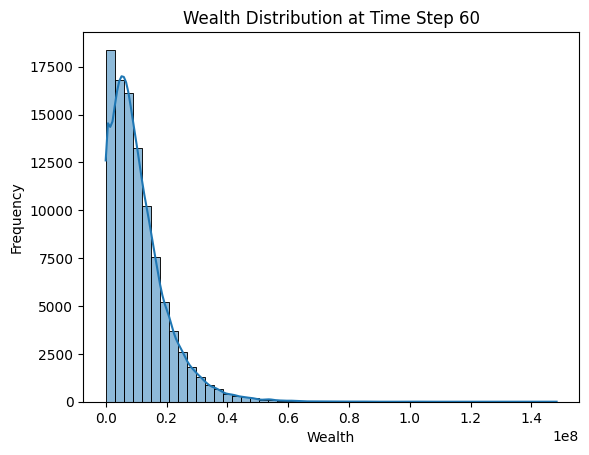

In [569]:
plot_wealth_distribution(wealth.cpu(), time_step=60)

In [345]:
cashflows        

tensor([ 10000.,  10000.,  10000.,  10000.,  10000.,  10000.,  10000.,  10000.,
         10000.,  10000.,  10000.,  10000.,  10000.,  10000.,  10000.,  10000.,
         10000.,  10000.,  10000.,  10000.,  10000.,  10000.,  10000.,  10000.,
         10000.,  10000.,  10000.,  10000.,  10000.,  10000., -80000., -80000.,
        -80000., -80000., -80000., -80000., -80000., -80000., -80000., -80000.,
        -80000., -80000., -80000., -80000., -80000., -80000., -80000., -80000.,
        -80000., -80000., -80000., -80000., -80000., -80000., -80000., -80000.,
        -80000., -80000., -80000., -80000.])

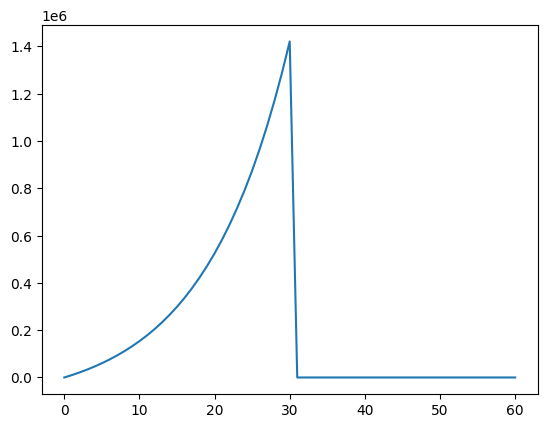

In [367]:
wealth[:, -1]

tensor([0., 0., 0.,  ..., 0., 0., 0.], grad_fn=<SelectBackward0>)

In [222]:
t = 26

W_steps = 10

contol_matrix = torch.tensor(np.array([np.array([0+W_step/10]*S_TIMESTEPS) for W_step in range(W_steps)]), requires_grad=True)

wealth_at_t = wealth.detach()[:, t]
wealth_grid = torch.tensor(
    # np.log(np.linspace(1, 1.5e7, W_steps))
    np.linspace(1, 1.5e7, W_steps)  # Use linear space for wealth grid
)

control = contol_matrix[:, t]

# torch.clamp(torch.searchsorted(wealth_grid, torch.log(wealth_at_t+1), right=True) - 1, 0, W_steps - 2)
lower_i = torch.clamp(
    torch.searchsorted(wealth_grid, wealth_at_t + 1, right=True) - 1, 0, W_steps-1
)
upper_i = torch.clamp(lower_i + 1, 0, W_steps-1)

w_0 = wealth_grid[lower_i]
w_1 = wealth_grid[upper_i]

beta = (wealth_at_t - w_0) / (w_1 - w_0)

w_0 = control[lower_i]
w_1 = control[upper_i]

w = w_0 + beta * (w_1 - w_0)
w = w.nan_to_num(nan=control.detach().numpy()[-1])  # Replace nan with last control value


In [223]:
w

tensor([0.4958, 0.4588, 0.4491, 0.8262, 0.2420, 0.3642, 0.5472, 0.4504, 0.4487,
        0.5126, 0.4094, 0.4901, 0.4203, 0.5099, 0.4110, 0.4013, 0.8880, 0.4920,
        0.4845, 0.4378, 0.5213, 0.8000, 0.5595, 0.8996, 0.7759, 0.2665, 0.4663,
        0.4761, 0.4355, 0.2391, 0.2687, 0.9000, 0.6151, 0.7021, 0.6499, 0.5638,
        0.2895, 0.5794, 0.4640, 0.4054, 0.7075, 0.4052, 0.9000, 0.6337, 0.4520,
        0.8374, 0.3879, 0.3711, 0.2594, 0.2746, 0.3132, 0.3860, 0.2920, 0.3393,
        0.2933, 0.4618, 0.5632, 0.5211, 0.3018, 0.4513, 0.6416, 0.4349, 0.4314,
        0.6440, 0.4838, 0.3887, 0.4036, 0.4776, 0.8136, 0.5247, 0.5143, 0.5582,
        0.3722, 0.3973, 0.5669, 0.6901, 0.4701, 0.2573, 0.3220, 0.5737, 0.3887,
        0.3636, 0.5784, 0.4408, 0.4618, 0.4653, 0.3059, 0.5020, 0.4408, 0.3669,
        0.2725, 0.4624, 0.4453, 0.5861, 0.3306, 0.5124, 0.4626, 0.8060, 0.3893,
        0.4441, 0.3479, 0.3795, 0.8021, 0.6351, 0.3263, 0.5282, 0.3374, 0.2685,
        0.7505, 0.3612, 0.6295, 0.2786, 

In [220]:
loss = w.sum()
loss.backward()

In [221]:
control_matrix.grad

tensor([[2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
         2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.],
        [2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
         2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.],
        [2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
         2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.],
        [2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
         2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.],
        [2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
         2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.],
        [2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
         2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.],
        [2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
         2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.],
        [2., 2., 2., 2., 2.

In [132]:
wealth_grid

tensor([1.0000e+00, 1.6667e+06, 3.3333e+06, 5.0000e+06, 6.6667e+06, 8.3333e+06,
        1.0000e+07, 1.1667e+07, 1.3333e+07, 1.5000e+07], dtype=torch.float64)

In [ ]:
w_1

tensor([10000000.3333,  5000000.6667,  8333333.7778,  6666667.2222,
         6666667.2222,  6666667.2222,  6666667.2222,  8333333.7778,
        11666666.8889, 13333333.4444,  6666667.2222,  8333333.7778,
         8333333.7778,  8333333.7778, 15000000.0000, 13333333.4444,
         8333333.7778, 15000000.0000,  8333333.7778,  5000000.6667,
         6666667.2222, 10000000.3333, 13333333.4444, 10000000.3333,
        15000000.0000,  8333333.7778,  5000000.6667,  8333333.7778,
         5000000.6667,  6666667.2222,  6666667.2222,  8333333.7778,
        15000000.0000,  6666667.2222,  8333333.7778, 13333333.4444,
         6666667.2222, 13333333.4444,  8333333.7778,  6666667.2222,
        11666666.8889,  8333333.7778,  8333333.7778,  8333333.7778,
        15000000.0000,  8333333.7778,  6666667.2222,  8333333.7778,
         8333333.7778,  3333334.1111,  8333333.7778,  6666667.2222,
         6666667.2222,  8333333.7778,  6666667.2222, 11666666.8889,
         3333334.1111,  8333333.7778, 11666666.8